# Лабораторная работа F4 — Обнаружение разряда по известной форме

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/f4.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/f4.html)**.

**Что разбираем.** Форма разряда двигательной единицы известна заранее — это
один и тот же короткий двухфазный всплеск. Вопрос: как найти его в записи,
где шум того же порядка, что и сам разряд? Порог по амплитуде тут почти
бесполезен: шум пробивает его столько же раз, сколько сигнал.

Три вещи, которые проверим в коде:

1. согласованный фильтр — это корреляция с известной формой, и он даёт
   **наибольшее** возможное отношение сигнал/шум на выходе; выигрыш считается
   заранее, из энергии шаблона;
2. насколько он обходит порог по СКЗ-огибающей из E4 — сравним на кривой
   «найдено против ложных срабатываний»;
3. где он перестаёт быть оптимальным: если шаблон не тот и если шум не белый,
   а такой же ЭМГ-фон — выигрыш тает, и это видно в числах.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Согласованный фильтр: откуда берётся формула

Ищем известную форму $s[n]$ длиной $M$ в смеси $x[n]=s[n-t_0]+\xi[n]$, где
$\xi$ — белый шум со среднеквадратичным отклонением $\sigma$. Пропустим смесь
через КИХ-фильтр с коэффициентами $h$ и посмотрим на выход в момент, где
сигнал целиком попал в окно фильтра:

$$ y = \sum_{k=0}^{M-1} h[k]\,s[M-1-k] \;+\; \sum_{k=0}^{M-1} h[k]\,\xi[\cdot] .$$

Первая сумма — полезный отклик, вторая — шум на выходе; её СКО равно
$\sigma\|h\|$. Отношение сигнал/шум на выходе:

$$ q = \frac{\bigl|\sum_k h[k]\,s[M-1-k]\bigr|}{\sigma\,\|h\|} .$$

Числитель — скалярное произведение двух векторов, и неравенство
Коши–Буняковского даёт $|\langle h, \tilde s\rangle| \le \|h\|\,\|s\|$, причём
**равенство достигается только когда $h$ пропорционален $\tilde s$** —
развёрнутой во времени копии шаблона. Отсюда сразу и фильтр, и предел:

$$ h[k] = \frac{s[M-1-k]}{\|s\|}, \qquad q_{\max} = \frac{\|s\|}{\sigma}
   = \frac{\sqrt{E_s}}{\sigma}. $$

Читается так: **выигрыш зависит только от энергии шаблона**, не от его формы
и не от того, длинный он или короткий. Никакая другая линейная обработка при
белом шуме больше не выжмет — это и есть смысл слова «оптимальный».

In [2]:
# ЯЧЕЙКА · Синтетическая ЭМГ из отдельных разрядов.
# Дальше все сигналы в этой работе строятся этими четырьмя функциями.
#
# Мышца состоит из двигательных единиц — мотонейрон плюс все волокна, которыми
# он управляет. Каждая единица разряжается 8–20 раз в секунду, и каждый разряд
# даёт на электроде короткий двухфазный всплеск: MUAP, потенциал действия
# двигательной единицы. Поверхностный электрод складывает разряды многих
# единиц — получается «интерференционная» ЭМГ, шумоподобная на вид.

import numpy as np


def muap(fs, ms=10.0):
    """Форма одного разряда: двухфазный всплеск длиной ms миллисекунд.

    Берём производную гауссианы — простейшая форма с двумя фазами и нулевым
    средним, то есть без постоянной составляющей, как у настоящего MUAP.
    """
    half = max(2, round(ms / 1000 * fs / 2))
    t = np.arange(2 * half + 1) - half
    sigma = (2 * half + 1) / 6
    shape = -(t / sigma ** 2) * np.exp(-t ** 2 / (2 * sigma ** 2))
    return shape / np.abs(shape).max()


def synth_emg(n, fs, units=10, seed=0):
    """Интерференционная ЭМГ: сумма разрядов нескольких двигательных единиц.

    У каждой единицы своя частота разрядов и своя амплитуда, а интервалы между
    разрядами слегка гуляют — поэтому сумма и выглядит шумоподобной.
    Результат нормирован на единичное СКО.
    """
    rng = np.random.default_rng(seed)
    shape = muap(fs)
    x = np.zeros(n)
    for _ in range(units):
        rate = rng.uniform(8, 20)                 # разрядов в секунду
        amplitude = rng.uniform(0.5, 1.5)
        position = rng.uniform(0, fs / rate)
        while position < n - len(shape):
            start = int(round(position))
            x[start:start + len(shape)] += amplitude * shape
            position += (fs / rate) * rng.uniform(0.75, 1.25)
    x /= np.sqrt(np.mean(x ** 2)) or 1.0
    return x + 0.05 * rng.standard_normal(n)      # шум усилителя


def mains_hum(n, fs):
    """Наводка от электросети: 50 Гц плюс гармоники 100 и 150 Гц."""
    t = np.arange(n) / fs
    return (np.sin(2 * np.pi * 50 * t)
            + 0.35 * np.sin(2 * np.pi * 100 * t)
            + 0.15 * np.sin(2 * np.pi * 150 * t))


def median_frequency(freqs, psd, band=(20.0, 450.0)):
    """MDF: частота, ниже которой лежит половина мощности сигнала в полосе.

    Считается по спектру мощности, поэтому качество оценки спектра прямо
    определяет, насколько устойчиво получается MDF.
    """
    inside = (freqs >= band[0]) & (freqs <= band[1])
    cumulative = np.cumsum(psd[inside])
    return float(freqs[inside][np.searchsorted(cumulative, cumulative[-1] / 2)])


print("Готово: muap, synth_emg, mains_hum, median_frequency")

Готово: muap, synth_emg, mains_hum, median_frequency


разряд 12 мс = 13 отсчётов; энергия шаблона E = 5.28, ||s|| = 2.30
теоретический выигрыш 20·lg||s|| = +7.2 дБ
ОСШ на входе  6.0 дБ   ОСШ на выходе 13.1 дБ   измеренный выигрыш +7.1 дБ
разрядов в записи: 162 за 20 с


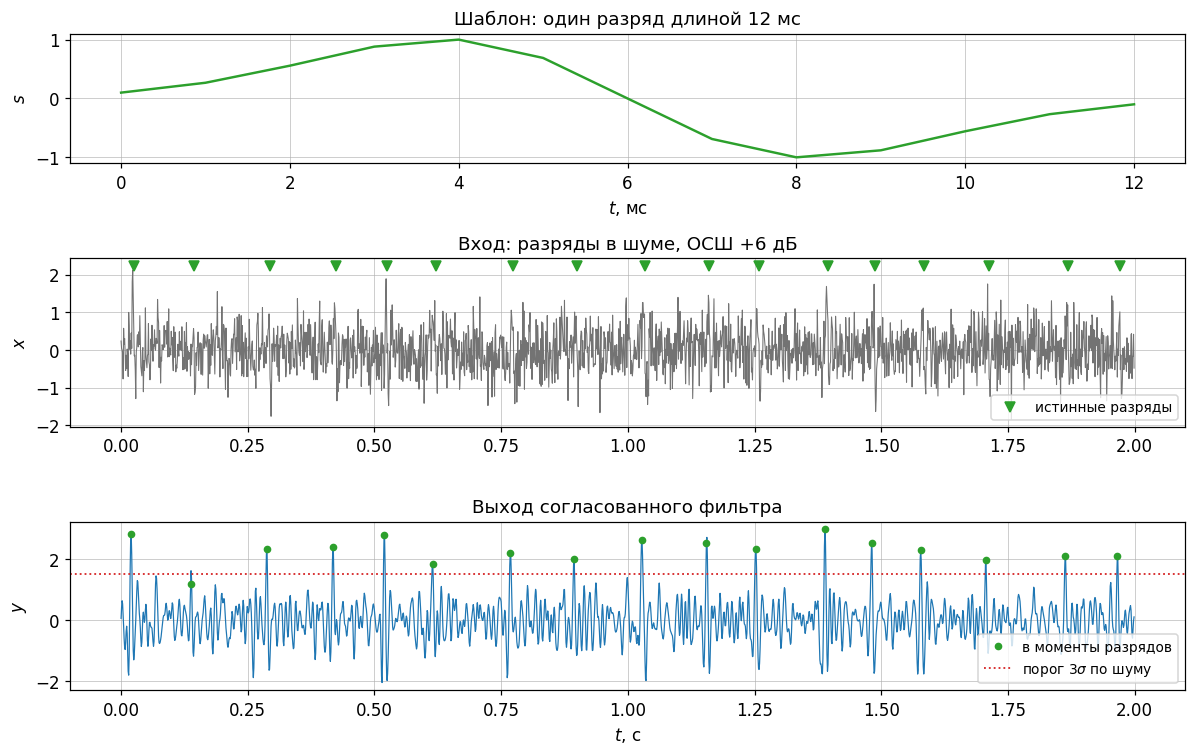

In [3]:
FS = 1000.0            # частота дискретизации, Гц
MS = 12.0              # длительность разряда, мс
SECONDS = 20.0         # длина записи
RATE = 8.0             # разрядов в секунду у нашей двигательной единицы
SNR_DB = 6.0           # амплитуда разряда к СКО шума, дБ

N = int(FS * SECONDS)
template = muap(FS, MS)                 # форма разряда: пик равен 1
M = len(template)
CENTER = M // 2                          # пик формы стоит в середине окна

rng = np.random.default_rng(20260826)
fire = []                                # моменты начала разрядов
position = rng.uniform(0, FS / RATE)
while position < N - M:
    fire.append(int(round(position)))
    position += FS / RATE * rng.uniform(0.7, 1.3)     # интервалы гуляют ±30 %
fire = np.array(fire)
centers = fire + CENTER                  # «истина»: где стоят пики разрядов

clean = np.zeros(N)
for t0 in fire:
    clean[t0:t0 + M] += template

sigma = 10 ** (-SNR_DB / 20)             # СКО шума при заданном ОСШ
noise = rng.standard_normal(N)
x = clean + sigma * noise

h = template[::-1] / np.linalg.norm(template)         # согласованный фильтр
y = np.convolve(x, h)[M - 1:M - 1 + N]                # выровнен на начало разряда

gain_theory = np.linalg.norm(template)
# шум на выходе меряем по шумовому пути отдельно: в самом y сидят ещё и разряды,
# и если взять СКО всего y, они завысят «шум» и занизят выигрыш
noise_out = np.convolve(sigma * noise, h)[M - 1:M - 1 + N]
snr_in = 1.0 / sigma                                   # пик разряда равен 1
snr_out = np.mean(y[fire]) / np.std(noise_out)

print("разряд %.0f мс = %d отсчётов; энергия шаблона E = %.2f, ||s|| = %.2f"
      % (MS, M, np.sum(template ** 2), gain_theory))
print("теоретический выигрыш 20·lg||s|| = %+.1f дБ" % (20 * np.log10(gain_theory)))
print("ОСШ на входе  %.1f дБ   ОСШ на выходе %.1f дБ   измеренный выигрыш %+.1f дБ"
      % (20 * np.log10(snr_in), 20 * np.log10(snr_out),
         20 * np.log10(snr_out / snr_in)))
print("разрядов в записи: %d за %.0f с" % (len(fire), SECONDS))

seg = slice(0, 2000)
t = np.arange(N)[seg] / FS
fig, ax = plt.subplots(3, 1, figsize=(11, 7.0),
                       gridspec_kw={"height_ratios": [1, 1.3, 1.3]})
ax[0].plot(np.arange(M) / FS * 1000, template, lw=1.6, color="tab:green")
ax[0].set(xlabel="$t$, мс", ylabel="$s$", title="Шаблон: один разряд длиной %.0f мс" % MS)
ax[1].plot(t, x[seg], lw=0.7, color="0.45")
ax[1].plot(centers[centers < seg.stop] / FS,
           np.full((centers < seg.stop).sum(), np.max(x[seg]) * 1.05),
           "v", color="tab:green", ms=6, label="истинные разряды")
ax[1].set(ylabel="$x$", title="Вход: разряды в шуме, ОСШ %+.0f дБ" % SNR_DB)
ax[1].legend(fontsize=9, loc="lower right")
ax[2].plot(t, y[seg], lw=0.8, color="tab:blue")
ax[2].plot(fire[fire < seg.stop] / FS, y[fire[fire < seg.stop]],
           "o", color="tab:green", ms=4, label="в моменты разрядов")
ax[2].axhline(3 * np.std(noise_out), color="tab:red", ls=":", lw=1.2,
              label="порог $3\\sigma$ по шуму")
ax[2].set(xlabel="$t$, с", ylabel="$y$", title="Выход согласованного фильтра")
ax[2].legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

Измеренный выигрыш совпадает с $20\lg\|s\|$ — считать его можно **до** опыта,
по одному шаблону. И сразу отрезвляющее сравнение: в радиолокации тот же
фильтр даёт 20–25 дБ, потому что там база сигнала (произведение полосы на
длительность) — сотни. У нашего разряда длительность 12 мс и полоса около
250 Гц, база порядка трёх — отсюда и скромные ~7 дБ. Согласованный фильтр
полезен здесь не сжатием, а тем, что он **оптимален**: лучше при белом шуме
не сделает никакая линейная обработка.

## Ячейка 3 · Против порога по огибающей: кривая обнаружения

В E4 уровень активности мерили СКЗ в скользящем окне, а в E10 по нему же
ловили начало сокращения. Это честный конкурент: он ничего не знает о форме
разряда, зато и не требует её знать. Сравним оба на одной записи.

Порог не выбираем — перебираем **все** и строим кривую: по горизонтали число
ложных срабатываний в секунду, по вертикали доля найденных разрядов. Такую
кривую в задачах поиска событий строят вместо обычной ROC, потому что
«отрицательных примеров» здесь нет — есть только поток ложных тревог.

при 1 ложном срабатывании в секунду найдено разрядов:
   согласованный фильтр  98 %
   порог по СКЗ (12 мс)  62 %

окно СКЗ подбираем честно, вдруг мы его просто плохо взяли:
   окно  6 мс: 69 %
   окно  8 мс: 69 %
   окно 10 мс: 69 %
   окно 12 мс: 62 %
   окно 16 мс: 53 %
   окно 25 мс: 20 %
   окно 50 мс: 2 %


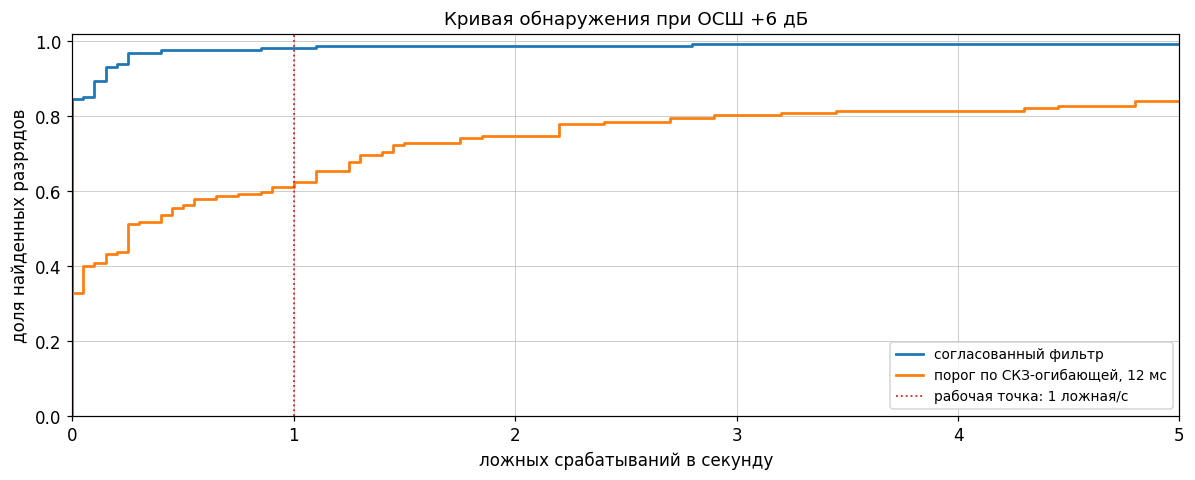

In [4]:
TOL = 8                    # попадание засчитываем, если пик ближе 8 мс к разряду
RMS_MS = 12.0              # окно СКЗ-огибающей, мс


def local_peaks(v):
    """Индексы локальных максимумов — кандидаты в обнаружения."""
    return np.where((v[1:-1] >= v[:-2]) & (v[1:-1] > v[2:]))[0] + 1


def rms_envelope(sig, ms):
    """СКЗ в скользящем окне — детектор из E4, центрированный."""
    w = max(2, int(round(ms / 1000 * FS)))
    return np.sqrt(np.convolve(sig ** 2, np.ones(w) / w, mode="same"))


def detection_curve(v, offset, truth, seconds):
    """Доля найденных событий против числа ложных срабатываний в секунду.

    Идём по кандидатам от самого высокого к самому низкому — это и есть
    перебор порога сверху вниз. Каждое истинное событие можно найти один раз.

    Повторный пик рядом с уже найденным разрядом не считаем ни попаданием, ни
    ложной тревогой: любой настоящий детектор ставит после срабатывания
    «мёртвую зону» и второй раз про то же событие не докладывает. Считать такие
    пики ошибками нечестно — их число зависит от того, насколько изрезан выход
    детектора, а не от того, насколько он хорош.
    """
    idx = local_peaks(v)
    order = np.argsort(-v[idx])
    found = np.zeros(len(truth), bool)
    hits = false_alarms = 0
    tp, fp = [], []
    for i in idx[order] + offset:
        nearest = np.argmin(np.abs(truth - i))
        if abs(truth[nearest] - i) <= TOL:
            if found[nearest]:
                continue                      # то же событие, уже засчитано
            found[nearest] = True
            hits += 1
        else:
            false_alarms += 1
        tp.append(hits / len(truth))
        fp.append(false_alarms / seconds)
    return np.array(fp), np.array(tp)


def tpr_at(fp, tp, rate=1.0):
    """Доля найденного при заданном темпе ложных тревог, событий в секунду."""
    k = np.searchsorted(fp, rate, side="right") - 1
    return tp[k] if k >= 0 else 0.0


env = rms_envelope(x, RMS_MS)
fp_mf, tp_mf = detection_curve(y, CENTER, centers, SECONDS)
fp_rms, tp_rms = detection_curve(env, 0, centers, SECONDS)

print("при 1 ложном срабатывании в секунду найдено разрядов:")
print("   согласованный фильтр  %.0f %%" % (100 * tpr_at(fp_mf, tp_mf)))
print("   порог по СКЗ (%.0f мс)  %.0f %%" % (RMS_MS, 100 * tpr_at(fp_rms, tp_rms)))
print("\nокно СКЗ подбираем честно, вдруг мы его просто плохо взяли:")
for ms in (6, 8, 10, 12, 16, 25, 50):
    e = rms_envelope(x, ms)
    f, t_ = detection_curve(e, 0, centers, SECONDS)
    print("   окно %2d мс: %.0f %%" % (ms, 100 * tpr_at(f, t_)))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(fp_mf, tp_mf, lw=1.8, color="tab:blue", label="согласованный фильтр")
ax.plot(fp_rms, tp_rms, lw=1.8, color="tab:orange",
        label="порог по СКЗ-огибающей, %.0f мс" % RMS_MS)
ax.axvline(1.0, color="tab:red", ls=":", lw=1.2, label="рабочая точка: 1 ложная/с")
ax.set(xlim=(0, 5), ylim=(0, 1.02), xlabel="ложных срабатываний в секунду",
       ylabel="доля найденных разрядов",
       title="Кривая обнаружения при ОСШ %+.0f дБ" % SNR_DB)
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

Разрыв есть, и он не от неудачного окна: перебор окон СКЗ от 6 до 50 мс
упирается в те же ~70 % против 98 %. Причина простая — огибающая знает только
про энергию в окне, а согласованный фильтр ещё и про **форму**: знак, порядок
фаз, длительность. Шумовой всплеск той же энергии, но другой формы, даёт на
выходе фильтра маленький отклик, а в огибающую попадает целиком.

Но сразу оговорка, потому что «в разы лучше» звучит красивее, чем есть на
самом деле. Разрыв зависит от ОСШ, и вот измеренная картина (лучшее окно СКЗ
из 6–12 мс, та же запись):

| ОСШ на входе | согласованный фильтр | лучший порог по СКЗ |
|---|---|---|
| +9 дБ и выше | 100 % | 99–100 % |
| +6 дБ | 98 % | 64 % |
| +3 дБ | 70 % | 31 % |
| 0 дБ | 32 % | 13 % |
| −6 дБ | единицы процентов | единицы процентов |

То есть выигрыш максимален посередине — там, где задача трудная, но ещё
решаемая, — и составляет примерно 2,5 раза. При высоком ОСШ форма не нужна:
разряд и так торчит над шумом. При очень низком не спасает уже ничто: 7 дБ
выигрыша просто не хватает, и оба детектора работают на уровне случайности,
где разница между 4 % и 8 % — это разница в несколько событий из полутора
сотен, то есть шум счёта, а не преимущество.

## Ячейка 4 · Чем платим: шаблон должен быть тот самый

Вся оптимальность держится на том, что форма известна точно. Возьмём фильтр,
согласованный с разрядом другой длительности, и посмотрим, сколько теряем.

истинная длительность разряда: 12 мс
   шаблон         потеря         косинус угла     20·lg cos
   6 мс           -2.3 дБ        0.758            -2.4 дБ
   9 мс           -0.9 дБ        0.903            -0.9 дБ
   12 мс          -0.1 дБ        1.000            +0.0 дБ
   16 мс          -0.5 дБ        0.946            -0.5 дБ
   20 мс          -1.5 дБ        0.843            -1.5 дБ
   24 мс          -2.7 дБ        0.735            -2.7 дБ
потеря меньше 1 дБ при длительности шаблона от 7 до 18 мс


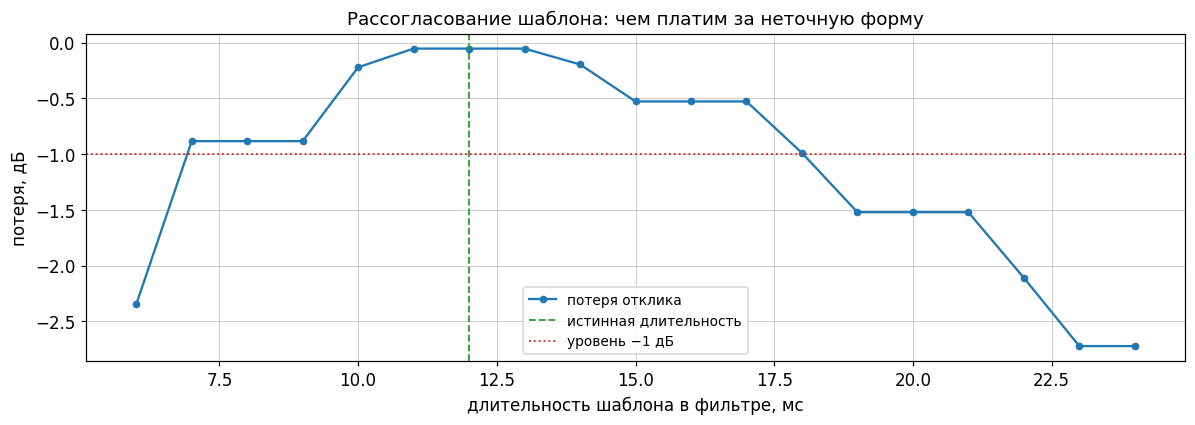

In [5]:
WIDTHS = np.arange(6.0, 25.0, 1.0)          # длительность шаблона в фильтре, мс

def centered(v, length):
    """Кладём форму в середину окна длиной length — чтобы сравнивать по времени."""
    out = np.zeros(length)
    start = (length - len(v)) // 2
    out[start:start + len(v)] = v
    return out


LONG = 81                                       # общее окно, 81 мс, с запасом
reference = centered(template, LONG)

loss_db, corr = [], []
for ms in WIDTHS:
    guess = muap(FS, ms)
    hh = guess[::-1] / np.linalg.norm(guess)
    # mode="same" совмещает середину фильтра с текущим отсчётом, поэтому пик
    # отклика стоит в центре разряда независимо от длины шаблона
    yy = np.convolve(x, hh, mode="same")
    peak = np.mean(yy[centers])                 # средний отклик на разрядах
    loss_db.append(20 * np.log10(peak / np.linalg.norm(template)))
    # то же самое, но без записи: косинус угла между формами на одной оси времени
    b = centered(guess, LONG)
    corr.append(float(np.dot(reference, b)
                      / (np.linalg.norm(reference) * np.linalg.norm(b))))

loss_db, corr = np.array(loss_db), np.array(corr)
print("истинная длительность разряда: %.0f мс" % MS)
print("   %-14s %-14s %-16s %s" % ("шаблон", "потеря", "косинус угла", "20·lg cos"))
for ms, l, c in zip(WIDTHS, loss_db, corr):
    if ms in (6.0, 9.0, 12.0, 16.0, 20.0, 24.0):
        print("   %-14s %-14s %-16s %s"
              % ("%.0f мс" % ms, "%+.1f дБ" % l, "%.3f" % c,
                 "%+.1f дБ" % (20 * np.log10(c))))
inside = WIDTHS[loss_db > -1.0]
print("потеря меньше 1 дБ при длительности шаблона от %.0f до %.0f мс"
      % (inside.min(), inside.max()))

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(WIDTHS, loss_db, "o-", lw=1.5, ms=4, color="tab:blue", label="потеря отклика")
ax.axvline(MS, color="tab:green", ls="--", lw=1.2, label="истинная длительность")
ax.axhline(-1.0, color="tab:red", ls=":", lw=1.2, label="уровень −1 дБ")
ax.set(xlabel="длительность шаблона в фильтре, мс", ylabel="потеря, дБ",
       title="Рассогласование шаблона: чем платим за неточную форму")
ax.legend(fontsize=9, loc="lower center")
fig.tight_layout()
plt.show()

Провал пологий: ошибиться на пару миллисекунд почти не страшно. Это и есть
причина, по которой шаблонное детектирование работает на реальных записях, где
форма разряда известна лишь приблизительно — её обычно берут как среднее по
нескольким уже найденным разрядам.

## Ячейка 5 · Где оптимальность кончается: шум не белый

Вывод через Коши–Буняковского опирался на белый шум. В настоящей записи мешает
не белый шум, а **фон работающей мышцы** — сумма разрядов остальных
двигательных единиц. Он состоит из тех же всплесков, то есть занимает ту же
полосу, что и наш шаблон. Проверим то же самое на таком фоне.

фон          ОСШ на выходе          СФ при 1 ложной/с      СКЗ при 1 ложной/с
белый шум    13.1 дБ                98 %                   69 %
фон ЭМГ      7.8 дБ                 13 %                   9 %


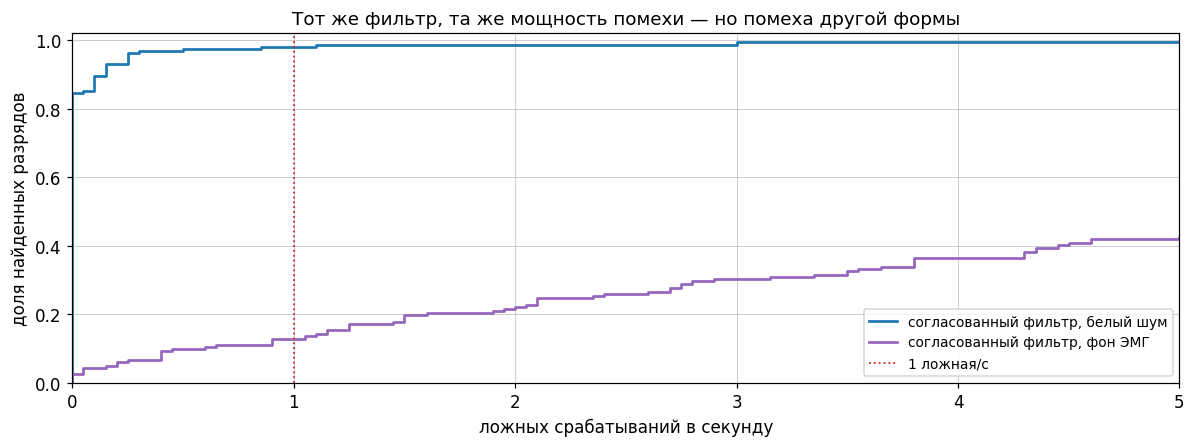

In [6]:
background = synth_emg(N, FS, units=14, seed=11)
background /= np.std(background)

print("%-12s %-22s %-22s %s" % ("фон", "ОСШ на выходе", "СФ при 1 ложной/с", "СКЗ при 1 ложной/с"))
curves = {}
for name, bg in (("белый шум", noise / np.std(noise)), ("фон ЭМГ", background)):
    xx = clean + sigma * bg
    yy = np.convolve(xx, h)[M - 1:M - 1 + N]
    nn = np.convolve(sigma * bg, h)[M - 1:M - 1 + N]      # только помеха, без разрядов
    ee = rms_envelope(xx, 6.0)
    f_mf, t_mf = detection_curve(yy, CENTER, centers, SECONDS)
    f_rms, t_rms = detection_curve(ee, 0, centers, SECONDS)
    curves[name] = (f_mf, t_mf)
    print("%-12s %-22s %-22s %s"
          % (name, "%.1f дБ" % (20 * np.log10(np.mean(yy[fire]) / np.std(nn))),
             "%.0f %%" % (100 * tpr_at(f_mf, t_mf)),
             "%.0f %%" % (100 * tpr_at(f_rms, t_rms))))

fig, ax = plt.subplots(figsize=(11, 4.2))
for name, color in (("белый шум", "tab:blue"), ("фон ЭМГ", "tab:purple")):
    f, t_ = curves[name]
    ax.plot(f, t_, lw=1.8, color=color, label="согласованный фильтр, %s" % name)
ax.axvline(1.0, color="tab:red", ls=":", lw=1.2, label="1 ложная/с")
ax.set(xlim=(0, 5), ylim=(0, 1.02), xlabel="ложных срабатываний в секунду",
       ylabel="доля найденных разрядов",
       title="Тот же фильтр, та же мощность помехи — но помеха другой формы")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

Мощность помехи одна и та же, фильтр тот же — а обнаружение рассыпается.
Причина в предпосылке вывода: при белом шуме энергия помехи размазана по всем
частотам поровну, и фильтр, собирающий сигнал, автоматически собирает
минимум помехи. Фон ЭМГ сидит ровно там же, где сигнал, поэтому фильтр честно
усиливает и его.

Что с этим делают: **обеляют** запись перед согласованной фильтрацией —
оценивают спектр помехи и делят на него, после чего помеха становится белой и
вывод снова работает. Это ровно та же идея, что и в оптимальном фильтре
Винера; в лабораторной мы её не строим, но знать, где проходит граница
применимости, обязательно.

## Задания

1. Поставь свои $ОСШ$ и длительность разряда из таблицы вариантов. Выпиши
   теоретический выигрыш $20\lg\|s\|$ и измеренный — сходятся?
2. Прогони ячейку 3 при `SNR_DB` = 12, 6, 3, 0, −3 дБ и построй зависимость
   «доля найденного при 1 ложной/с» от ОСШ для обоих детекторов. При каком ОСШ
   согласованный фильтр перестаёт находить хотя бы половину разрядов?
3. Увеличь `RATE` до 25 разрядов в секунду. Разряды начнут накладываться друг
   на друга. Что происходит с долей найденного и почему это не лечится порогом?
4. В ячейке 4 замени ошибку по длительности на ошибку по знаку: подай в фильтр
   `-template`. На сколько дБ упадёт отклик? Объясни через скалярное
   произведение.
5. В ячейке 5 подними ОСШ до 12 дБ. На фоне ЭМГ фильтр снова начинает
   работать — при каком ОСШ разница между двумя фонами исчезает совсем и
   почему?